<a href="https://colab.research.google.com/github/YafetG3/A02-eda-and-visualization/blob/main/Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Yafet Getachew

**Date:** 9/9/2026

In [1]:
# Your Phase 1 solution to the problem goes here.


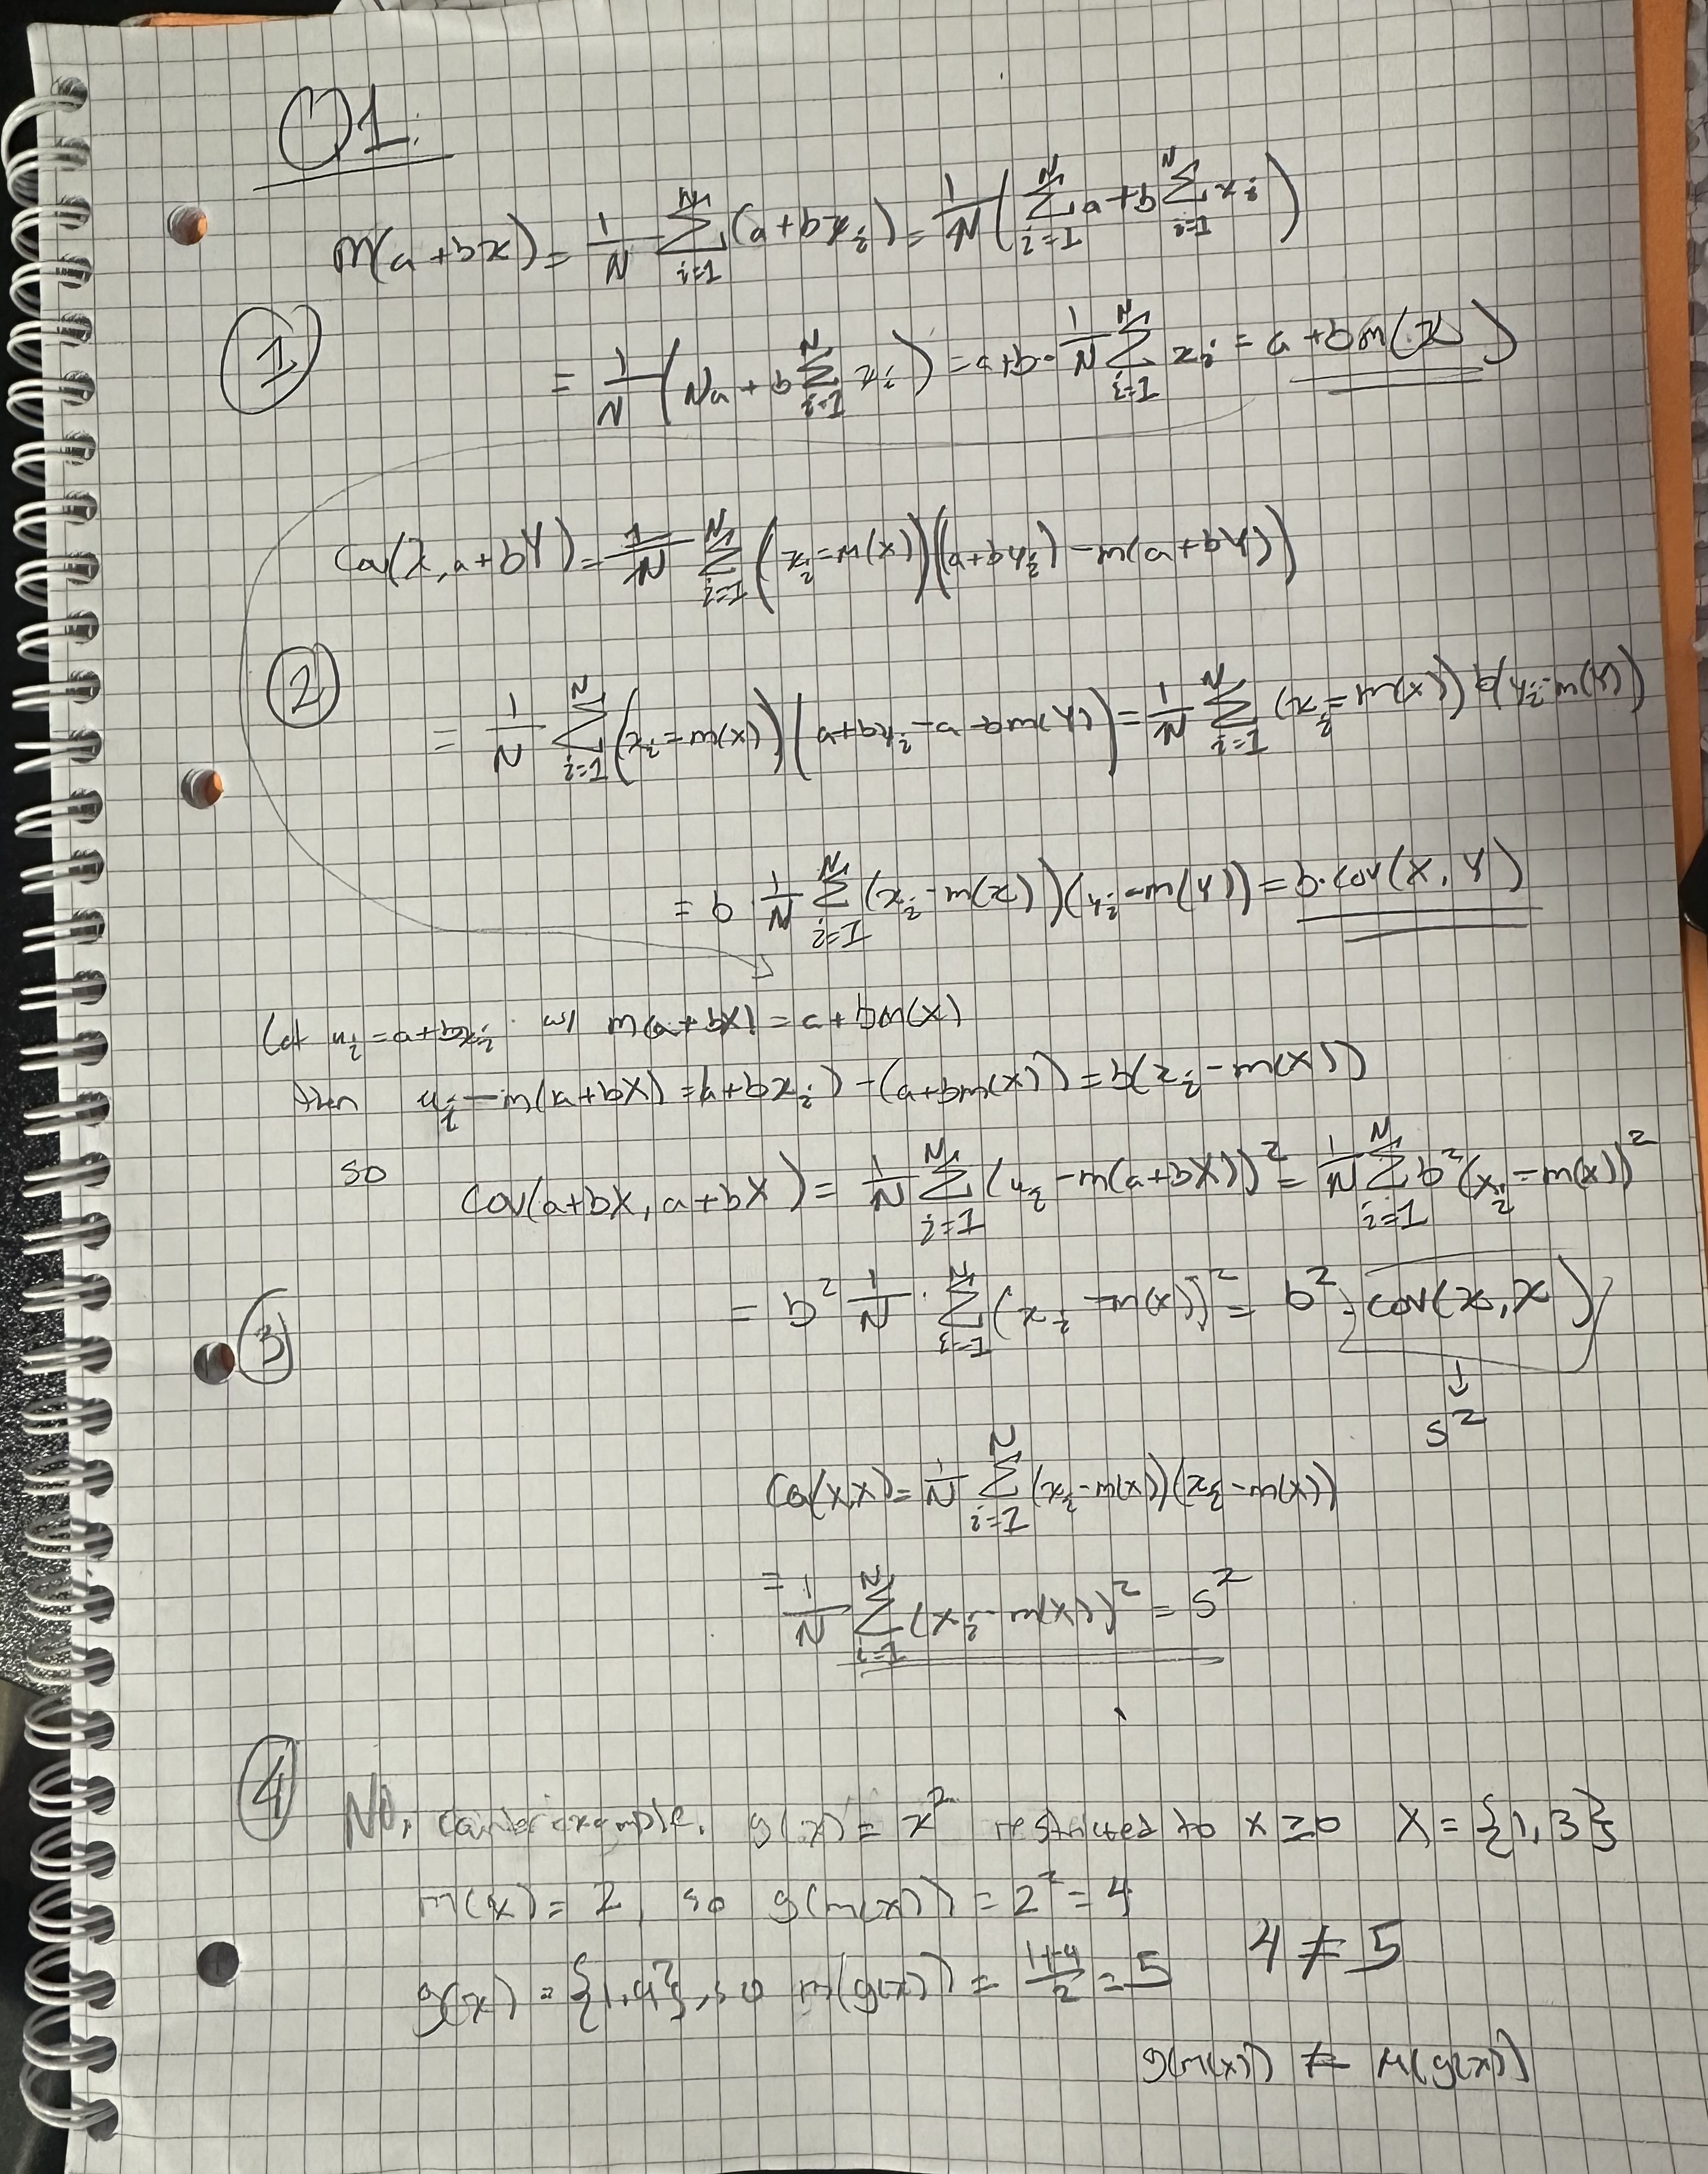

##Q2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
url = 'https://raw.githubusercontent.com/YafetG3/A02-eda-and-visualization/refs/heads/main/data/ForeignGifts_edu.csv'
df = pd.read_csv(url, low_memory=False)

In [3]:
print("df.shape:")
print(df.shape, '\n')

print("df.dtypes:")
print(df.dtypes, '\n')

df.head()

df.shape:
(28221, 10) 

df.dtypes:
ID                             int64
OPEID                          int64
Institution Name              object
City                          object
State                         object
Foreign Gift Received Date     int64
Foreign Gift Amount            int64
Gift Type                     object
Country of Giftor             object
Giftor Name                   object
dtype: object 



,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


count    2.822100e+04
mean     5.882327e+05
std      3.222011e+06
min     -5.377700e+05
25%      5.700000e+03
50%      9.461500e+04
75%      3.761420e+05
max      1.000000e+08
Name: Foreign Gift Amount, dtype: float64
Negative amounts: 24


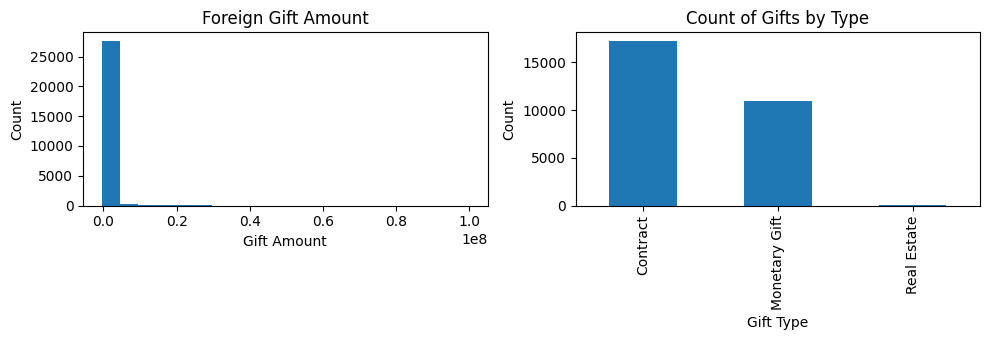

In [15]:
print(df['Foreign Gift Amount'].describe())
print("Negative amounts:", (df['Foreign Gift Amount'] < 0).sum())

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
df["Foreign Gift Amount"].hist(bins=20, grid=False, ax=axes[0])
axes[0].set(title="Foreign Gift Amount", xlabel="Gift Amount", ylabel="Count")

df["Gift Type"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set(title="Count of Gifts by Type", xlabel="Gift Type", ylabel="Count")
plt.tight_layout()
plt.show()

##Q2.2
The Foreign Gift Amount variable is right-skewed and across all the gifts, the mean of around 588,000 dollars is way higher than the median of roughly 94,600 dollars, meaning a small number of very large gifts pull the average up. I noticed there are also 24 negative values which I'm thinking could be refunds or a transaction being reversed somehow. Because of the skew, what stands out to me in the histogram is a very tall bar (contract) near 0 followed by a slightly smaller bar (monetary gift), with the rest of the distribution (real estate) being barely visible.

In [18]:
gift_type_props = df['Gift Type'].value_counts(normalize=True) * 100
print(gift_type_props)

Gift Type
Contract         61.209737
Monetary Gift    38.751285
Real Estate       0.038978
Name: proportion, dtype: float64


##Q2.3
Porportions:
Contract = ~61%
Monetary gift = ~38%
Real estate gift = ~1%

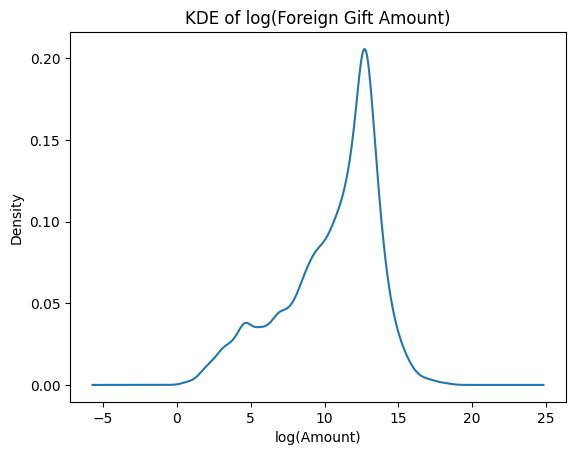

In [5]:
#KDE for Foreign Gift Amount
df['log_amount'] = df['Foreign Gift Amount'].apply(lambda x: np.log1p(x) if x > 0 else np.nan)
x = df['log_amount'].dropna().values

N = len(x)
sample_sd = np.std(x, ddof=1)
h_s = 1.06 * sample_sd * N**(-1 / 5)
grid = np.linspace(x.min() - 2 * sample_sd, x.max() + 2 * sample_sd, 500)

def normal_kernel(center, bandwidth):
    z = (grid - center) / bandwidth
    return np.exp(-(z**2) / 2) / (bandwidth * np.sqrt(2 * np.pi))

kde = sum(normal_kernel(value, h_s) for value in x) / N
ax = sns.lineplot(x=grid, y=kde)
ax.set(title="KDE of log(Foreign Gift Amount)", xlabel="log(Amount)", ylabel="Density")
plt.show()

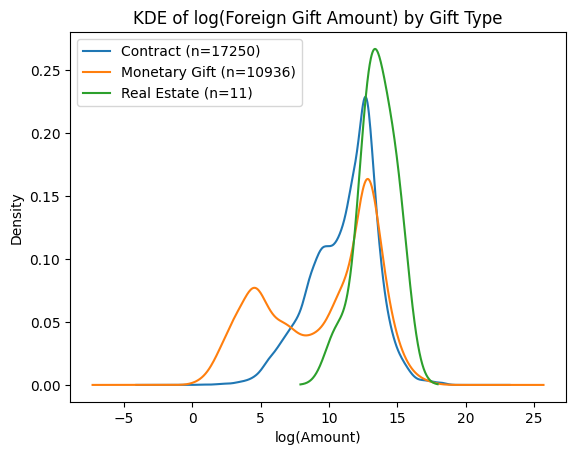

In [6]:
#KDE for Foreign Gift Amount, by Gift Type
fig, ax = plt.subplots()

for gift_type, group in df.groupby('Gift Type'):
    x = group['log_amount'].dropna().values

    N = len(x)
    sample_sd = np.std(x, ddof=1)
    h_s = 1.06 * sample_sd * N**(-1 / 5)
    grid = np.linspace(x.min() - 2 * sample_sd, x.max() + 2 * sample_sd, 500)

    def normal_kernel(center, bandwidth):
        z = (grid - center) / bandwidth
        return np.exp(-(z**2) / 2) / (bandwidth * np.sqrt(2 * np.pi))

    kde = sum(normal_kernel(value, h_s) for value in x) / N
    sns.lineplot(x=grid, y=kde, label=f"{gift_type} (n={N})", ax=ax)

ax.set(title="KDE of log(Foreign Gift Amount) by Gift Type", xlabel="log(Amount)", ylabel="Density")
plt.legend()
plt.show()

##Q2.4
After the log transformation, the distribution becomes less skewed and a bit more bell-shaped and breaking it down by gift type shows some real differences.Specifically, the range of the contract values fall a bit tightly around a mid-range value, with a median of 110,000 dollars, while Monetary Gifts are more spread out as they range from small donations to very large ones with a median of 50,000 dollars (with more variation). Although the Real Estate gifts are a less prominent (there are only like 11 in the data) they tend to be on the higher end with a median of 668,000 dollars, which makes sense since gifts to do with real estate usually involve more money than monetary gifts and contracts.

In [19]:
#Top 15 countries in terms of the number of gifts
print(df['Country of Giftor'].value_counts().head(15))

Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: count, dtype: int64


In [20]:
#Top 15 countries in terms of the amount given
print(df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15))

Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUSTRALIA                248409202
Name: Foreign Gift Amount, dtype: int64


In [21]:
#Giftors providing the most money in total
top_giftors = df.groupby('Giftor Name')['Foreign Gift Amount'].sum().sort_values(ascending=False)
print(top_giftors.head(15))

Giftor Name
Qatar Foundation                       1166503744
Qatar Foundation/Qatar National Res     796197000
Qatar Foundation for Education          373945215
Anonymous                               338793629
Saudi Arabian Cultural Mission          275221475
HCL                                     190000000
Church of Jesus Christ of LDS           185203715
Emirates Institute for Advanced Sc      170641244
QIC                                     148355497
Anonymous #9                             96334996
Qatar National Research Fund             79021705
Government of Saudi Arabia               75192434
Contracting Party                        69996984
CMKL University                          67700000
Royal Embassy of Saudi Arabia            67062486
Name: Foreign Gift Amount, dtype: int64


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** e03e4fb191d0172df7e378e37e7fb1f6520f84cd
- **AI tool and model used:** Claude Sonnet 5 medium

### *Prompts used

1. [Pasted the assignment and my code for phase 1] Help provide suggestions/propose changes to my code for phase 2 of this assignment
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. The raw-scale histogram (Cell 10) is dominated by one bar because of the extreme right skew — consider adding a log-scaled x-axis version alongside it, so the shape of the bulk of the data is visible without needing to jump to the separate log-KDE plot later.
2. The normal_kernel function is redefined inside the for loop in Cell 15 — it's identical each iteration. Pull it out above the loop (or reuse the one from Cell 14) to avoid redundant code.
3. In the top-15 country/giftor outputs, the dollar amounts print as raw integers (e.g., 2706240869). Formatting with commas (.map('{:,.0f}'.format)) would make these easier to read.


### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Reject | The assignment doesn't require a log-scaled histogram specifically especially since we create a log kde plot later |
| 2 | Accept | Accepted as it the suggestion would help remove duplicate code by defining the kernel once instead of twice |
| 3 | Accept | Similar to assignment 1 this ai is proposing a stylistic change, specifically adding commas to make the money more readable which I do think could be useful so I added it. |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [9]:
# Your Phase 2 solution to the problem goes here.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
url = 'https://raw.githubusercontent.com/YafetG3/A02-eda-and-visualization/refs/heads/main/data/ForeignGifts_edu.csv'
df = pd.read_csv(url, low_memory=False)

print("df.shape:")
print(df.shape, '\n')

print("df.dtypes:")
print(df.dtypes, '\n')

df.head()

print(df['Foreign Gift Amount'].describe())
print("Negative amounts:", (df['Foreign Gift Amount'] < 0).sum())

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
df["Foreign Gift Amount"].hist(bins=20, grid=False, ax=axes[0])
axes[0].set(title="Foreign Gift Amount", xlabel="Gift Amount", ylabel="Count")

df["Gift Type"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set(title="Count of Gifts by Type", xlabel="Gift Type", ylabel="Count")
plt.tight_layout()
plt.show()

gift_type_props = df['Gift Type'].value_counts(normalize=True) * 100
print(gift_type_props)

def normal_kernel(center, bandwidth, grid):
    z = (grid - center) / bandwidth
    return np.exp(-(z**2) / 2) / (bandwidth * np.sqrt(2 * np.pi))

#KDE for Foreign Gift Amount
df['log_amount'] = df['Foreign Gift Amount'].apply(lambda x: np.log1p(x) if x > 0 else np.nan)
x = df['log_amount'].dropna().values

N = len(x)
sample_sd = np.std(x, ddof=1)
h_s = 1.06 * sample_sd * N**(-1 / 5)
grid = np.linspace(x.min() - 2 * sample_sd, x.max() + 2 * sample_sd, 500)

kde = sum(normal_kernel(value, h_s, grid) for value in x) / N
ax = sns.lineplot(x=grid, y=kde)
ax.set(title="KDE of log(Foreign Gift Amount)", xlabel="log(Amount)", ylabel="Density")
plt.show()

#KDE for Foreign Gift Amount, by Gift Type
fig, ax = plt.subplots()

for gift_type, group in df.groupby('Gift Type'):
    x = group['log_amount'].dropna().values

    N = len(x)
    sample_sd = np.std(x, ddof=1)
    h_s = 1.06 * sample_sd * N**(-1 / 5)
    grid = np.linspace(x.min() - 2 * sample_sd, x.max() + 2 * sample_sd, 500)

    kde = sum(normal_kernel(value, h_s, grid) for value in x) / N
    sns.lineplot(x=grid, y=kde, label=f"{gift_type} (n={N})", ax=ax)

ax.set(title="KDE of log(Foreign Gift Amount) by Gift Type", xlabel="log(Amount)", ylabel="Density")
plt.legend()
plt.show()

In [22]:
#Top 15 countries in terms of the number of gifts
print(df['Country of Giftor'].value_counts().head(15).map('{:,}'.format))

Country of Giftor
ENGLAND            3,655
CHINA              2,461
CANADA             2,344
JAPAN              1,896
SWITZERLAND        1,676
SAUDI ARABIA       1,610
FRANCE             1,437
GERMANY            1,394
HONG KONG          1,080
SOUTH KOREA          811
QATAR                693
THE NETHERLANDS      512
KOREA                452
INDIA                434
TAIWAN               381
Name: count, dtype: object


In [23]:
#Top 15 countries in terms of the amount given
top_countries_amount = df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)
print(top_countries_amount.map('${:,.0f}'.format))

Country of Giftor
QATAR                   $2,706,240,869
ENGLAND                 $1,464,906,771
CHINA                   $1,237,952,112
SAUDI ARABIA            $1,065,205,930
BERMUDA                   $899,593,972
CANADA                    $898,160,656
HONG KONG                 $887,402,529
JAPAN                     $655,954,776
SWITZERLAND               $619,899,445
INDIA                     $539,556,490
GERMANY                   $442,475,605
UNITED ARAB EMIRATES      $431,396,357
FRANCE                    $405,839,396
SINGAPORE                 $401,157,692
AUSTRALIA                 $248,409,202
Name: Foreign Gift Amount, dtype: object


In [24]:
#Giftors providing the most money in total
top_giftors = df.groupby('Giftor Name')['Foreign Gift Amount'].sum().sort_values(ascending=False)
print(top_giftors.head(15).map('${:,.0f}'.format))

Giftor Name
Qatar Foundation                       $1,166,503,744
Qatar Foundation/Qatar National Res      $796,197,000
Qatar Foundation for Education           $373,945,215
Anonymous                                $338,793,629
Saudi Arabian Cultural Mission           $275,221,475
HCL                                      $190,000,000
Church of Jesus Christ of LDS            $185,203,715
Emirates Institute for Advanced Sc       $170,641,244
QIC                                      $148,355,497
Anonymous #9                              $96,334,996
Qatar National Research Fund              $79,021,705
Government of Saudi Arabia                $75,192,434
Contracting Party                         $69,996,984
CMKL University                           $67,700,000
Royal Embassy of Saudi Arabia             $67,062,486
Name: Foreign Gift Amount, dtype: object


### *Reflection on AI assistance
In your own words without generative AI.

Main improvements include the fact that the ai is very good at findings ways to make things more effecient and readable, as seen by reccomendations 2 and 3, however, looking at suggestion 1 it's clear that it doesn't always have enough context. Specifically it didn't realize that the assignment didn't specifiy to create a log histogram for a reason, seeing as the assignment later wanted us to creat the log kde plots so we can compare the difference between that and the raw historgram plot. The final solution was verified by making sure any changes didn't actually change anythign significant, as I double checked with the original. Leading into the lesson learned, which is that, similar to the first assignment, I think one of the main concerns I have with using ai is also what I found in this assignment. There are a lot of things that you can miss when blindly just using ai and over trust can lead to a lot of small problems that can add up at the end.